**Project TEAMID** - PTID-CDS-JUL-26-11218

**Project CODE** - PRCP-1025-FlightPricePrediction

**Project Name** - Flight Price Prediction



**Project Type** - Supervised Machine Learning

**Contribution** - Individual

### 1. Introduction
Flight Price Prediction is a supervised machine learning regression project that predicts flight ticket prices based on various factors such as airline, journey date, source, destination, departure time, arrival time, duration, and number of stops.

The Airline Flight Price Dataset contains information about airline journeys and their corresponding ticket prices. The primary objective of this analysis is to understand the factors that influence flight ticket prices and identify meaningful patterns in airline operations, routes, journey dates, flight duration, departure times, and number of stops.

### 2. Executive Summary
Flight ticket prices are highly dynamic and can change significantly depending on several factors such as airline, route, journey date, departure time, flight duration, and number of stops. This unpredictability makes it difficult for customers to determine the right time to book a flight and for airlines to establish appropriate prices.

This project addresses the problem using Data Analysis and Machine Learning.

The project has two major objectives:

Task 1 — Data Analysis
To perform a complete exploratory data analysis (EDA) of the flight dataset and identify the factors that influence flight ticket prices.

Task 2 — Predictive Modeling
To develop a machine-learning regression model capable of predicting the expected price of a flight based on its characteristics. Such a system can help customers estimate future ticket prices and plan their journeys accordingly.

The dataset contains the following variables:

* Airline
* Date_of_Journey
* Source
* Destination
* Route
* Dep_Time
* Arrival_Time
* Duration
* Total_Stops
* Additional_Info
* Price
  
The variable Price is the dependent/target variable because the main analytical objective is to understand and eventually predict flight ticket prices.

### 3. Problem Statement
Flight ticket prices can be difficult to predict. A price observed today may be different tomorrow for the same flight. Travelers often experience this unpredictability when planning their journeys.

Therefore, the objective of this project is to use historical flight data and machine-learning techniques to:

1. Analyze the factors affecting flight ticket prices.
2. Identify patterns and relationships within the dataset.
3. Build a predictive model that estimates flight prices.
4. Help customers make better travel-planning and booking decisions.
5. Provide airlines with information that can support pricing strategies.
   
This is fundamentally a supervised machine-learning regression problem, because the model predicts a continuous numerical value: the flight ticket price.

### 4. Domain Analysis
The dataset contains the following columns:

| Column | Description | Type |
|:---|:---|:---:|
| Airline | Name of the airline | Categorical |
| Date_of_Journey | Date on which the journey takes place | Date |
| Source | Departure city | Categorical |
| Destination | Arrival city | Categorical |
| Route | Complete flight route | Categorical |
| Dep_Time | Departure time | Time |
| Arrival_Time | Arrival time | Time |
| Duration | Total flight duration | String/Time |
| Total_Stops | Number of stops during journey | Categorical |
| Additional_Info | Additional information about the flight | Categorical |
| Price | Flight ticket price | Numerical |


## 5. Business Problems

- **Unpredictable Flight Prices:** Ticket prices change frequently based on various factors.
- **Difficult Travel Planning:** Customers find it difficult to plan their travel budget.
- **Lack of Price Estimation:** Customers cannot easily determine whether a ticket price is high or low.
- **Airline Pricing Decisions:** Airlines need better insights into factors affecting ticket prices.
- **Revenue Optimization:** Accurate price prediction can support better pricing strategies.

### 6. Business Objective

To develop a **Flight Price Prediction System** that predicts ticket prices and helps customers make better travel and booking decisions.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
df = pd.read_excel("Flight_Fare.xlsx")

### Understanding Data

In [3]:
print("Shape: ", df.shape)

Shape:  (10683, 11)


In [4]:
print("Dataset: \n")
df.head()

Dataset: 



,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
print("Columns : \n")
print(df.columns)

Columns : 

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')


In [6]:
print("Inforation of dataset: \n " )
print(df.info())

Inforation of dataset: 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB
None


In [7]:
print("Unique Values: ",df.nunique().sum())

Unique Values:  4013


In [8]:
print("Statistical Summary of numerical columns: \n")
print(df.describe())

Statistical Summary of numerical columns: 

              Price
count  10683.000000
mean    9087.064121
std     4611.359167
min     1759.000000
25%     5277.000000
50%     8372.000000
75%    12373.000000
max    79512.000000


In [9]:
print("Statistical summary of categorical culumns: \n")
print(df.describe(include='object'))

Statistical summary of categorical culumns: 

            Airline Date_of_Journey Source Destination            Route  \
count         10683           10683  10683       10683            10682   
unique           12              44      5           6              128   
top     Jet Airways      18/05/2019  Delhi      Cochin  DEL → BOM → COK   
freq           3849             504   4537        4537             2376   

       Dep_Time Arrival_Time Duration Total_Stops Additional_Info  
count     10683        10683    10683       10682           10683  
unique      222         1343      368           5              10  
top       18:55        19:00   2h 50m      1 stop         No info  
freq        233          423      550        5625            8345  


### Handling missing values

In [10]:
print("Missing Values: \n")
print(df.isnull().sum())


Missing Values: 

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64


In [11]:
df['Route'] = df['Route'].fillna(df['Route'].mode()[0])
df['Total_Stops'] = df['Total_Stops'].fillna(df['Total_Stops'].mode()[0])

print("After Removed Missing Valuse: \n", df.isnull().sum())

After Removed Missing Valuse: 
 Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64


In [12]:
print("Duplicates: ", df.duplicated().sum())

Duplicates:  220


In [13]:
df = df.drop_duplicates()
print("After removing duplicates:", df.duplicated().sum())

After removing duplicates: 0


# Feature Engineering

### Extacting date of journey

In [14]:
df['Date_of_Journey']=pd.to_datetime(df['Date_of_Journey'],format='%d/%m/%Y',errors='coerce')
df['Journey_Day']=df['Date_of_Journey'].dt.day
df['Journey_Month']=df['Date_of_Journey'].dt.month

### Extracting Dep_Time

In [15]:
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'], format = '%H:%M')
df['Dep_Hours'] = df['Dep_Time'].dt.hour
df['Dep_Minutes'] = df['Dep_Time'].dt.minute

### Extracting Arrival time

In [16]:
df['Arrival_Hours'] = pd.to_datetime(df['Arrival_Time'].str[:5], format = '%H:%M', errors = 'coerce').dt.hour
df['Arrival_Minutes'] = pd.to_datetime(df['Arrival_Time'].str[:5], format = '%H:%M', errors = 'coerce').dt.minute

### Extracting Duration

In [17]:
df['Duration_Hours'] = df['Duration'].str.extract(r'(\d+)h').fillna(0).astype(int)
df['Duration_Minutes'] = df['Duration'].str.extract(r'(\d+)m').fillna(0).astype(int)

df['Total_Duration_Minutes'] = (
    df['Duration_Hours'] * 60 + df['Duration_Minutes']
)

In [18]:
df.drop(['Date_of_Journey','Dep_Time','Arrival_Time','Duration'], axis = 1, inplace=True)

### Converting Total_Sptos into numeric

In [19]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [20]:
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4   
})

print(df['Total_Stops'].dtype)
print(df['Total_Stops'].unique())

int64
[0 2 1 3 4]


# Exploratry Data Analysis

In [21]:
print(df['Airline'].value_counts())
print(df['Source'].value_counts())
print(df['Destination'].value_counts())
print(df['Total_Stops'].value_counts())

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1695
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64
Source
Delhi       4346
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64
Destination
Cochin       4346
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64
Total_Stops
1    5626
0    3475
2    1318
3      43
4       1
Name: count, dtype: int64


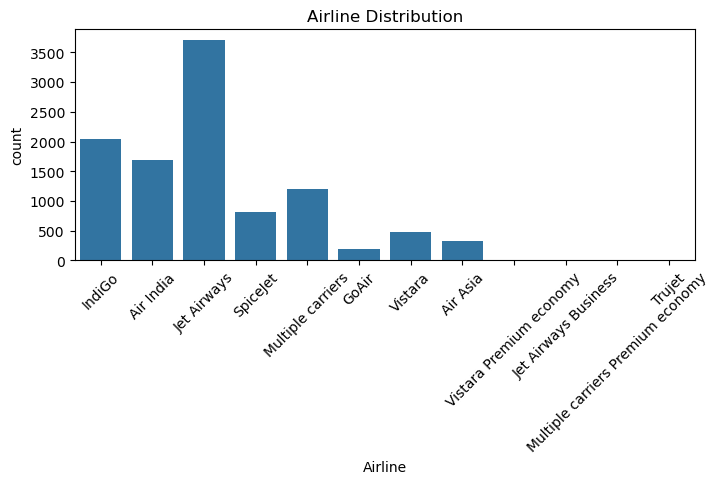

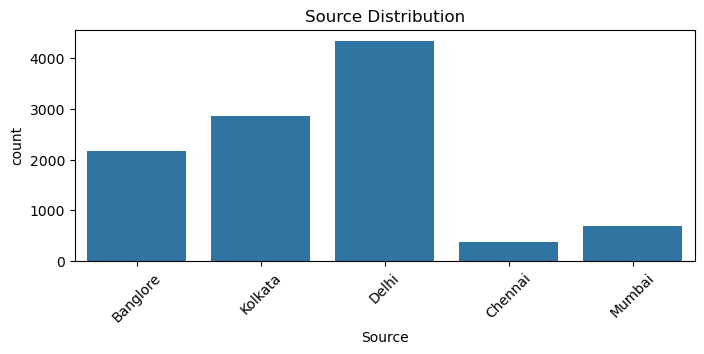

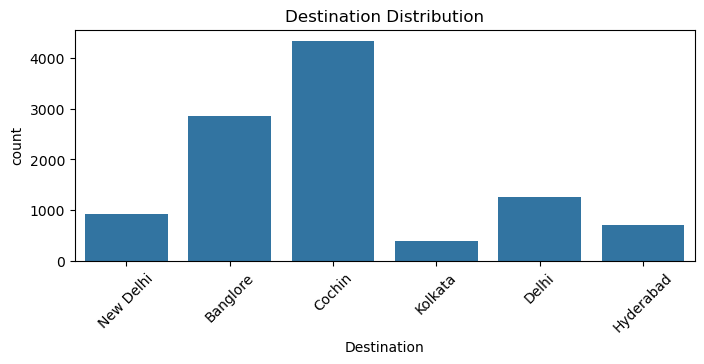

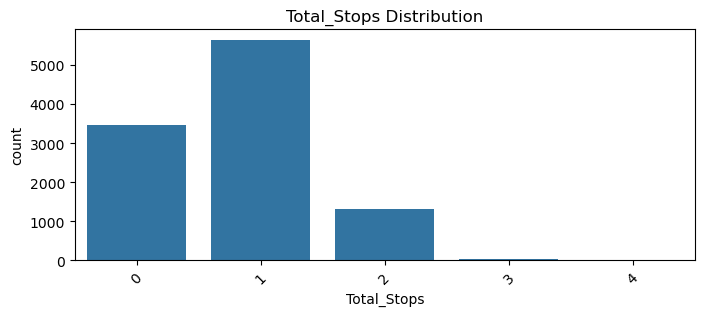

In [22]:
cat_cols = ['Airline', 'Source', 'Destination', 'Total_Stops']
for col in cat_cols:
    plt.figure(figsize = (8,3))
    sns.countplot(data=df, x=df[col])
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()


### Univariate Analysis Report
#### Airline
The Airline variable is categorical and represents the different airlines operating in the dataset. Univariate analysis helps identify which airlines have the highest and lowest number of flights and understand the distribution of flights among different airlines.

##### Source
The Source variable represents the departure city. Its analysis shows which cities have the highest number of flights and helps understand the distribution of flight departures.

##### Destination
The Destination variable represents the arrival city. Univariate analysis helps identify the most frequently used destinations and the overall distribution of flights across different cities.

##### Duration
The Duration variable represents the total travel time. Univariate analysis helps understand the range of flight durations and identify unusually short or long journeys.

#### Total_Stops
The Total_Stops variable indicates the number of stops in a journey. Its distribution helps determine whether most flights are non-stop or involve one or more connecting stops.

## Price Distribution Analysis

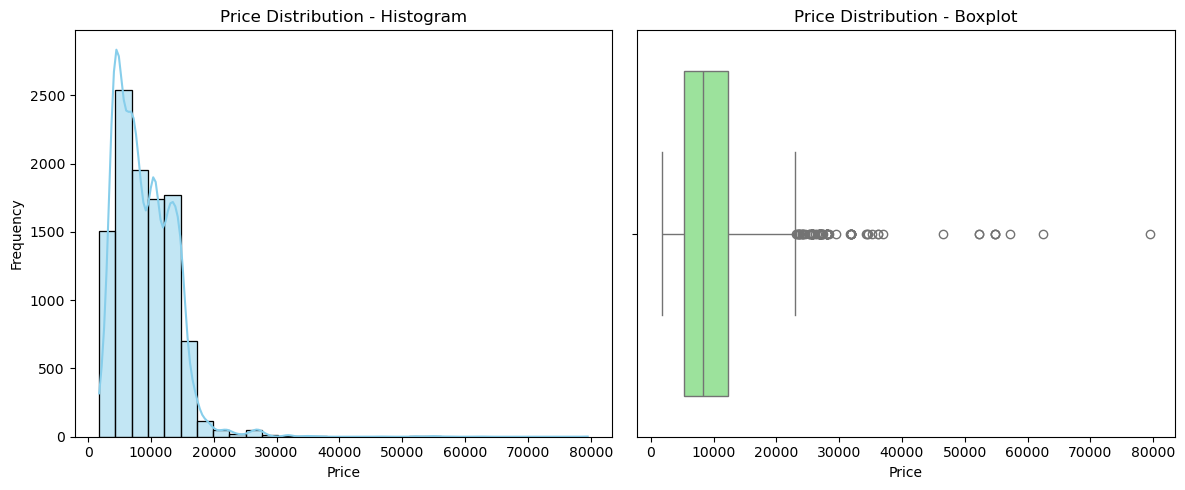

In [23]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["Price"], bins=30, kde=True, color="skyblue")
plt.title("Price Distribution - Histogram")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["Price"], color="lightgreen")
plt.title("Price Distribution - Boxplot")
plt.xlabel("Price")

plt.tight_layout()
plt.show()

In [24]:
df['Price'].skew

<bound method Series.skew of 0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10463, dtype: int64>

## Price Distribution Analysis

The distribution of flight ticket prices is analyzed using a histogram and a boxplot.

- The **histogram** shows the frequency distribution and overall shape of ticket prices.
- The **boxplot** shows the median, quartiles, spread, and potential outliers in ticket prices.
- The KDE curve in the histogram helps visualize the underlying density of the price distribution.


### Bivariate Analysis

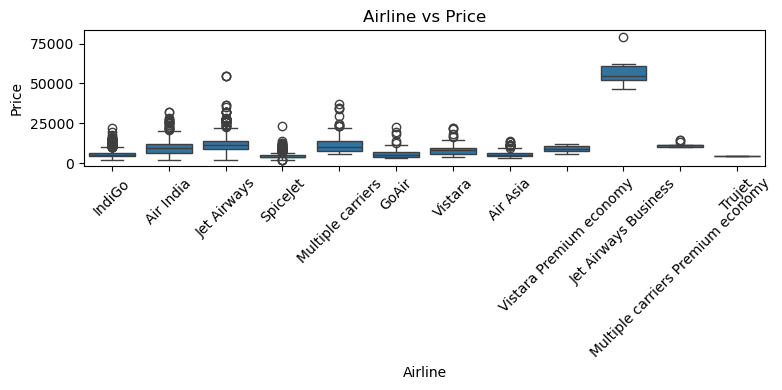

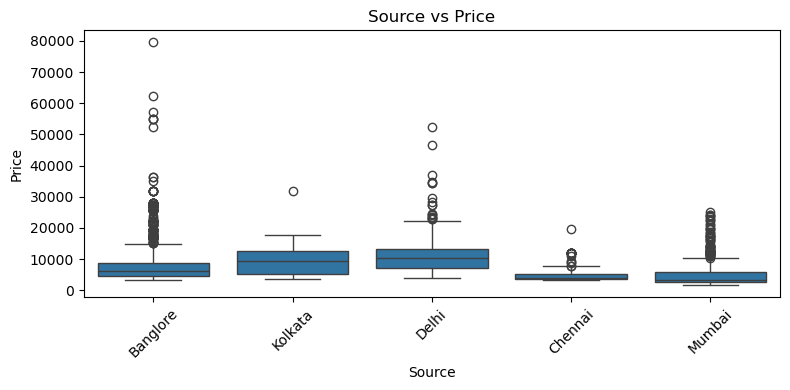

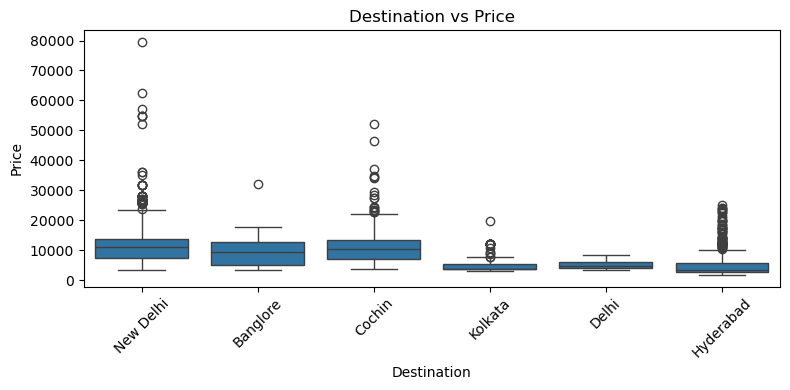

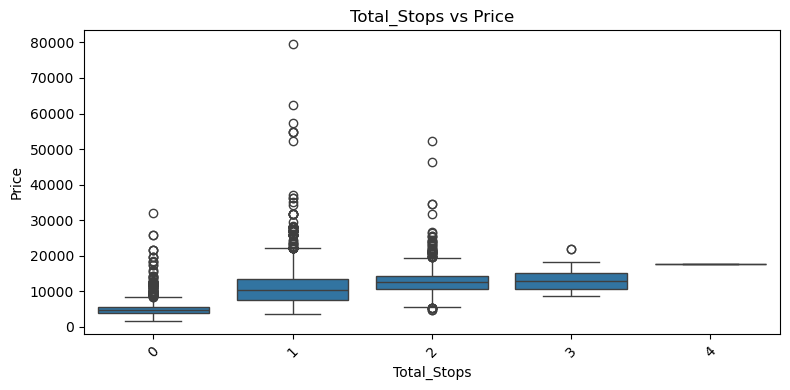

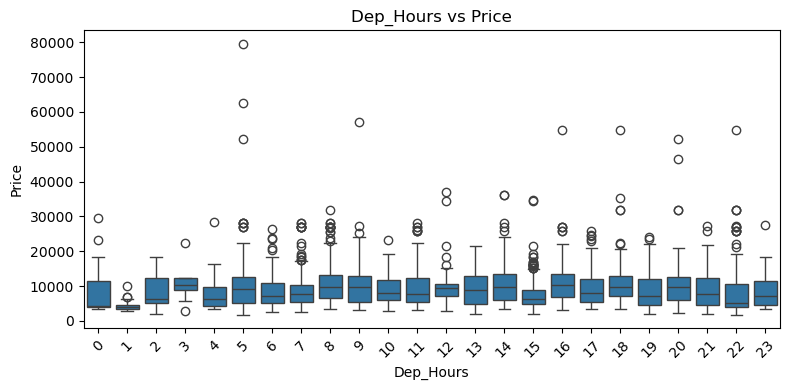

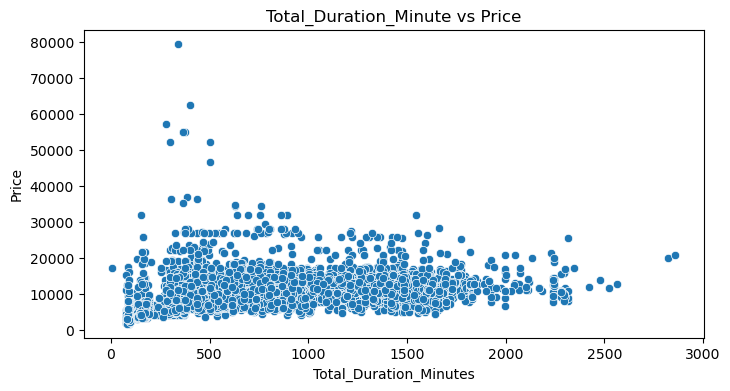

In [25]:
cols = ['Airline', 'Source', 'Destination', 'Total_Stops','Dep_Hours']

for col in cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df['Price'], data=df)
    plt.title(f"{col} vs Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(x=df['Total_Duration_Minutes'], y = df['Price'], data=df)
plt.title("Total_Duration_Minute vs Price")
plt.show()

# Insights:
The exploratory analysis establishes the following important relationships:

### 1. Airline
Ticket prices vary between airlines. Airline should therefore be included as a model feature.

### 2. Route
Different routes have different pricing patterns. Route is expected to be one of the strongest categorical predictors.

### 3. Number of Stops
The number of stops influences both convenience and pricing.

### 4. Duration
Longer journeys may have different pricing characteristics than shorter journeys.

### 5. Journey Date
Prices can vary by month and day of travel due to demand and seasonality.

#### 6. Departure and Arrival Time
Time-related variables can capture differences in demand and convenience.

##  Outliers Analysis

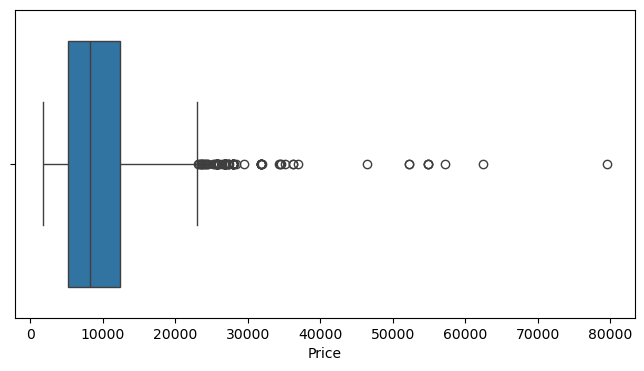

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Price', data=df)
plt.show()

In [27]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

print("Number of outliers:", len(outliers))


Number of outliers: 94


## Preprocesssing

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Airline'] = le.fit_transform(df['Airline'])
df['Source'] = le.fit_transform(df['Source'])
df['Destination'] = le.fit_transform(df['Destination'])
df['Route'] = le.fit_transform(df['Route'])
df['Additional_Info'] = le.fit_transform(df['Additional_Info'])

In [29]:
print("New Dataset: \n")
df.head()

New Dataset: 



,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hours,Dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes,Total_Duration_Minutes
0,3,0,5,18,0,8,3897,24,3,22,20,1,10,2,50,170
1,1,3,0,84,2,8,7662,1,5,5,50,13,15,7,25,445
2,4,2,1,118,2,8,13882,9,6,9,25,4,25,19,0,1140
3,3,3,0,91,1,8,6218,12,5,18,5,23,30,5,25,325
4,3,0,5,29,1,8,13302,1,3,16,50,21,35,4,45,285


## Correlation Analysis

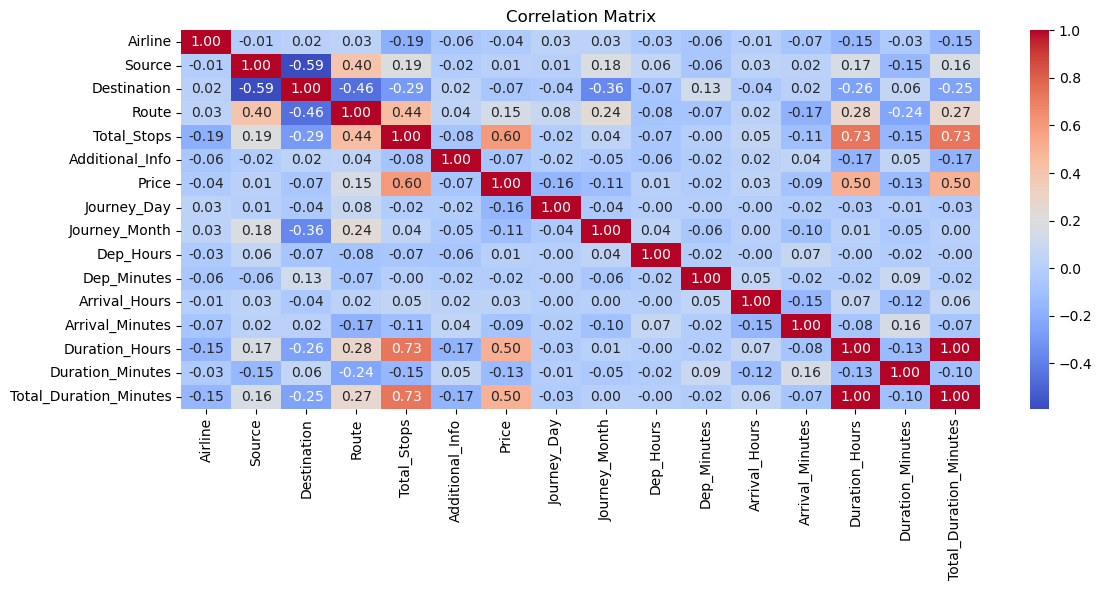

In [30]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Feature selection

In [31]:
x = df.drop('Price', axis = 1)
y = np.log1p(df['Price'])

## Split Train, Test Data

In [32]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42 )

In [33]:
print("Training Data: ", x_train.shape)
print("Testing Data: ", x_test.shape)

Training Data:  (8370, 15)
Testing Data:  (2093, 15)


## Linear Regression Model

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()

lr_model.fit(x_train, y_train)
y_pred = lr_model.predict(x_test)

print("Intercept: ", lr_model.intercept_)
print("Slope Coefficient: ", lr_model.coef_[0])

lr_mae = mean_absolute_error(y_test, y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = mean_squared_error(y_test, y_pred) ** 0.5
lr_r2 = r2_score(y_test, y_pred)

print("Linear Ression: \n")
print("MAE: ", lr_mae)
print("MSE: ", lr_mse)
print("RMSE: ", lr_rmse)
print("R2: ",lr_r2)


Intercept:  9.039887639712926
Slope Coefficient:  0.018341465624919583
Linear Ression: 

MAE:  0.27984233347743864
MSE:  0.1194335415663038
RMSE:  0.34559158202465495
R2:  0.5482083863572389


## Decision Tree

In [35]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth = 3, random_state =42)

dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)

dt_mae = mean_absolute_error(y_test, y_pred)
dt_mse = mean_squared_error(y_test, y_pred)
dt_rmse = mean_squared_error(y_test, y_pred) ** 0.5
dt_r2 = r2_score(y_test, y_pred)

print("Decision Tree Results:")
print("MAE: ", dt_mae)
print("MSE: ", dt_mse)
print("RMSE: ", dt_rmse)
print("R2: ", dt_r2)

Decision Tree Results:
MAE:  0.23082404582392968
MSE:  0.08933991719817065
RMSE:  0.29889783739293035
R2:  0.6620461486418826


## KNN

In [37]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor( n_neighbors=5)

knn_model.fit(x_train, y_train)
y_pred = knn_model.predict(x_test)

knn_mae = mean_absolute_error(y_test, y_pred)
knn_mse = mean_squared_error(y_test, y_pred)
knn_rmse = mean_squared_error(y_test, y_pred) ** 0.5
knn_r2 = r2_score(y_test, y_pred)

print("Random Forest Results:")
print("MAE: ", knn_mae)
print("MSE: ", knn_mse)
print("RMSE: ", knn_rmse)
print("R2: ",knn_r2)

Random Forest Results:
MAE:  0.17254008657739067
MSE:  0.06231474709538244
RMSE:  0.24962921923401202
R2:  0.7642766029144834


## Random Forest

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 10,
    random_state = 42
    
)

rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)

rf_mae = mean_absolute_error(y_test, y_pred)
rf_mse = mean_squared_error(y_test, y_pred)
rf_rmse = mean_squared_error(y_test, y_pred) ** 0.5
rf_r2 = r2_score(y_test, y_pred)

print("Random Forest Results:")
print("MAE: ", rf_mae)
print("MSE: ", rf_mse)
print("RMSE: ", rf_rmse)
print("R2: ", rf_r2)

Random Forest Results:
MAE:  0.09118046238109515
MSE:  0.02007030382206106
RMSE:  0.14166969973166832
R2:  0.9240783214568284


## GBR

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    random_state = 42
)

gbr_model.fit(x_train, y_train)
y_pred = gbr_model.predict(x_test)

gbr_mae = mean_absolute_error(y_test, y_pred)
gbr_mse = mean_squared_error(y_test, y_pred)
gbr_rmse = mean_squared_error(y_test, y_pred) ** 0.5
gbr_r2 = r2_score(y_test, y_pred)

print("GBR Results:")
print("MAE: ", gbr_mae)
print("MSE: ", gbr_mse)
print("RMSE: ", gbr_rmse)
print("R2: ", gbr_r2)

GBR Results:
MAE:  0.1369187279665716
MSE:  0.034437779071188605
RMSE:  0.18557418751321156
R2:  0.8697292270429094


## XGBR

In [40]:
from xgboost import XGBRegressor

xgbr_model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

xgbr_model.fit(x_train, y_train)
y_pred = xgbr_model.predict(x_test)

xgbr_mae = mean_absolute_error(y_test, y_pred)
xgbr_mse = mean_squared_error(y_test, y_pred)
xgbr_rmse = mean_squared_error(y_test, y_pred) ** 0.5
xgbr_r2 = r2_score(y_test, y_pred)

print("XGBR Results:")
print("MAE: ", xgbr_mae)
print("MSE: ", xgbr_mse)
print("RMSE: ", xgbr_rmse)
print("R2: ", xgbr_r2)

XGBR Results:
MAE:  0.09276884790053166
MSE:  0.018660363788495126
RMSE:  0.13660294209311571
R2:  0.9294118238762527


### Model Comparison

In [41]:
results = pd.DataFrame({
    "models": ["Linear Regression", "Decision Tree", "KNN", "Random Forest", "GBR", "XGBR" ],
    "MAE": [lr_mae, dt_mae, knn_mae, rf_mae, gbr_mae, xgbr_mae],
    "MSE": [lr_mse, dt_mse, knn_mse, rf_mse, gbr_mse, xgbr_mse],
    "RMSE": [lr_rmse, dt_rmse, knn_rmse, rf_rmse, gbr_rmse, xgbr_rmse],
    "R2" : [lr_r2, dt_r2, knn_r2, rf_r2, gbr_r2, xgbr_r2]
})

results

,models,MAE,MSE,RMSE,R2
0,Linear Regression,0.279842,0.119434,0.345592,0.548208
1,Decision Tree,0.230824,0.089340,0.298898,0.662046
2,KNN,0.172540,0.062315,0.249629,0.764277
3,Random Forest,0.091180,0.020070,0.141670,0.924078
4,GBR,0.136919,0.034438,0.185574,0.869729
5,XGBR,0.092769,0.018660,0.136603,0.929412


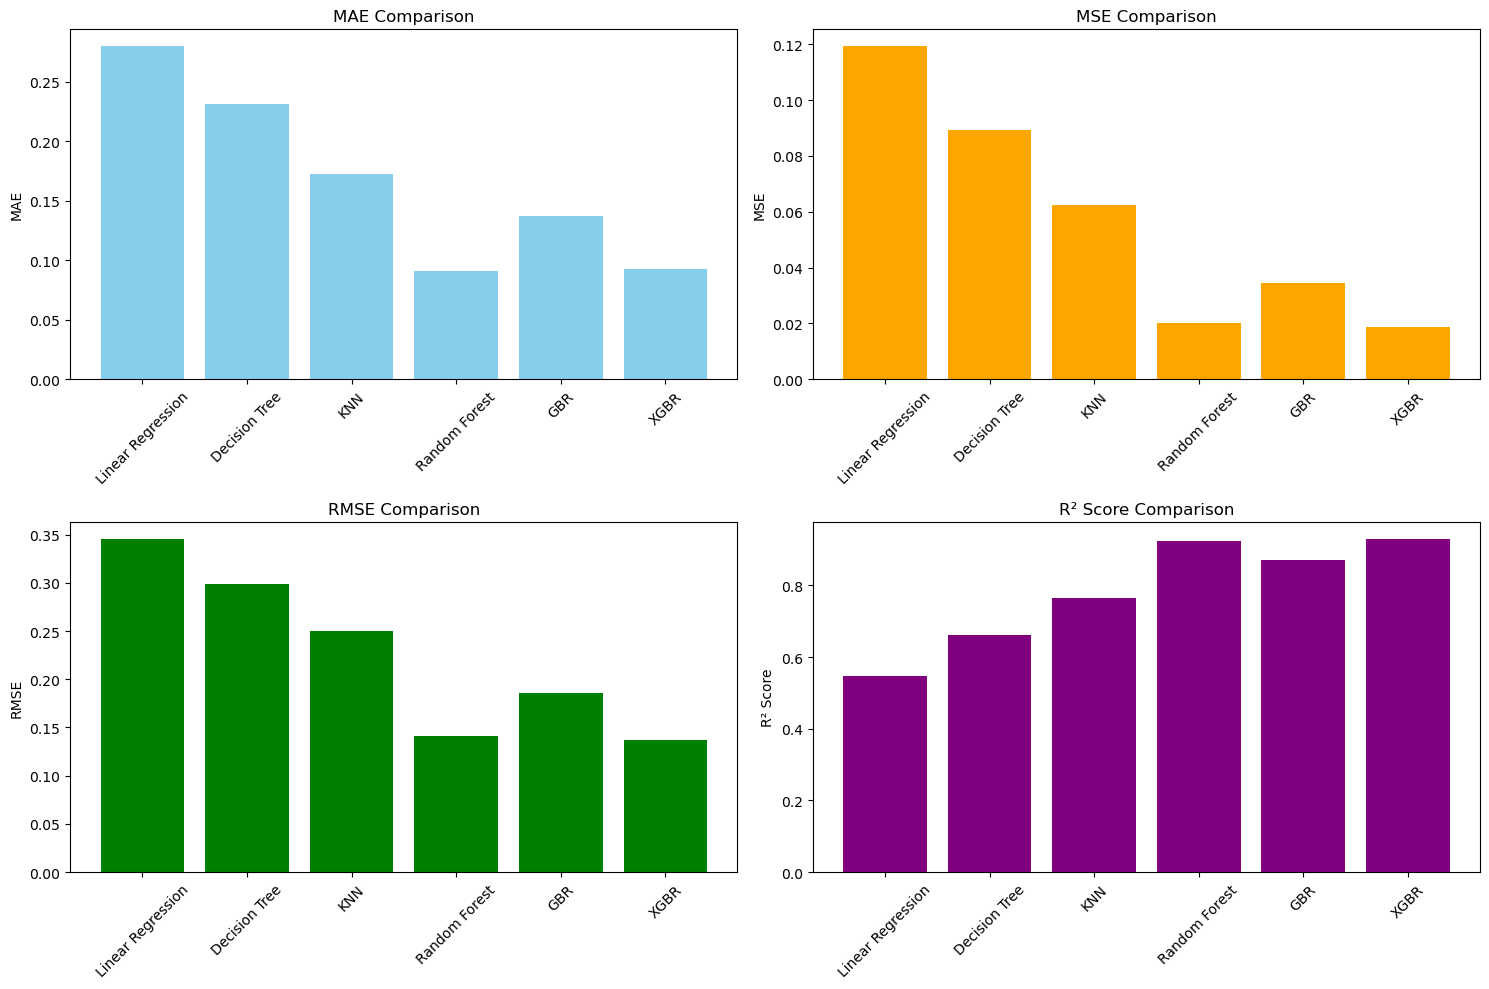

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# MAE
axes[0, 0].bar(results["models"], results["MAE"], color="skyblue")
axes[0, 0].set_title("MAE Comparison")
axes[0, 0].set_ylabel("MAE")
axes[0, 0].tick_params(axis="x", rotation=45)

# MSE
axes[0, 1].bar(results["models"], results["MSE"], color="orange")
axes[0, 1].set_title("MSE Comparison")
axes[0, 1].set_ylabel("MSE")
axes[0, 1].tick_params(axis="x", rotation=45)

# RMSE
axes[1, 0].bar(results["models"], results["RMSE"], color="green")
axes[1, 0].set_title("RMSE Comparison")
axes[1, 0].set_ylabel("RMSE")
axes[1, 0].tick_params(axis="x", rotation=45)

# R2
axes[1, 1].bar(results["models"], results["R2"], color="purple")
axes[1, 1].set_title("R² Score Comparison")
axes[1, 1].set_ylabel("R² Score")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# Model Comparison Report

Six machine-learning models were evaluated using MAE, MSE, RMSE, and R². For MAE, MSE, and RMSE, lower values indicate better performance, while for R², higher values indicate better performance.

### 1. Linear Regression
Linear Regression achieved the weakest overall performance, with an R² of 0.5482 and an RMSE of 0.3456. This indicates that the model explains approximately 54.82% of the variance in the target variable. Its relatively high error suggests that the relationship between the predictors and target is likely more complex than a simple linear relationship.

### 2. Decision Tree
The Decision Tree improved upon Linear Regression, achieving an R² of 0.6620 and an RMSE of 0.2989. Although it can capture nonlinear relationships, its performance remains considerably lower than the ensemble-based models.

### 3. KNN
KNN performed better than both Linear Regression and Decision Tree. It achieved an R² of 0.7643, with an RMSE of 0.2496 and MAE of 0.1725. This indicates that neighboring observations contain useful information for predicting the target, although KNN still falls behind the ensemble methods.

### 4. Random Forest
Random Forest showed a significant improvement, achieving an R² of 0.9241 and an RMSE of 0.1417. Its MAE of 0.0912 is the lowest among all six models. This indicates that Random Forest provides highly accurate predictions and is substantially better than the individual Decision Tree.

### 5. Gradient Boosting Regressor (GBR)
GBR also performed strongly, with an R² of 0.8697 and an RMSE of 0.1856. However, it was less accurate than both Random Forest and XGBR. Its MAE of 0.1369 indicates a higher average prediction error than the two best-performing models.

### 6. XGBoost Regressor (XGBR)
XGBR achieved the best overall performance. It produced the lowest MSE (0.0187) and RMSE (0.1366) and the highest R² (0.9294). Its MAE (0.0928) was also very close to Random Forest's 0.0912.

Therefore, based on the available evaluation metrics, XGBR is the best-performing model overall, while Random Forest is a very close second.

Overall ranking

Based primarily on R² and RMSE:

🥇 XGBR — R² = 0.9294, RMSE = 0.1366

🥈 Random Forest — R² = 0.9241, RMSE = 0.1417

🥉 GBR — R² = 0.8697, RMSE = 0.1856

KNN — R² = 0.7643, RMSE = 0.2496

Decision Tree — R² = 0.6620, RMSE = 0.2989

Linear Regression — R² = 0.5482, RMSE = 0.3456

### Conclusion

The results demonstrate that ensemble tree-based models substantially outperform Linear Regression, Decision Tree, and KNN for this dataset. XGBR achieved the highest explanatory power, with an R² of 92.94%, meaning it explains approximately 92.94% of the variation in the target variable. Random Forest performed almost equally well and obtained the lowest MAE.

For further improvement, hyperparameter tuning should be applied to XGBR and Random Forest, particularly parameters such as tree depth, number of estimators, learning rate (for XGBR/GBR), minimum samples per split/leaf, and feature sampling. Cross-validation should then be used to determine whether the improvement generalizes to unseen data.

# Hyperparameter Tuning 

## Tunned XGBR

In [43]:
from sklearn.model_selection import GridSearchCV

xgb_model = XGBRegressor(
    random_state=42
)

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(x_train, y_train)

print("Best Parameters:")
print(xgb_grid.best_params_)

print("Best CV R2:")
print(xgb_grid.best_score_)

xgb_best_model = xgb_grid.best_estimator_

xgb_tuned_pred = xgb_best_model.predict(x_test)

xgb_tuned_mae = mean_absolute_error(y_test, xgb_tuned_pred)
xgb_tuned_mse = mean_squared_error(y_test, xgb_tuned_pred)
xgb_tuned_rmse = np.sqrt(xgb_tuned_mse)
xgb_tuned_r2 = r2_score(y_test, xgb_tuned_pred)

print("\nTuned XGBR Results")
print("MAE:", xgb_tuned_mae)
print("MSE:", xgb_tuned_mse)
print("RMSE:", xgb_tuned_rmse)
print("R2:", xgb_tuned_r2)


Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Best CV R2:
0.9457846487099234

Tuned XGBR Results
MAE: 0.07071082024169044
MSE: 0.013849843804579992
RMSE: 0.11768535934677683
R2: 0.9476089949346628


## Tuned Random Forest

In [44]:
rf_model = RandomForestRegressor(
    random_state=42
)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("Best CV R2:")
print(rf_grid.best_score_)

rf_best_model = rf_grid.best_estimator_

rf_tuned_pred = rf_best_model.predict(x_test)

rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)
rf_tuned_mse = mean_squared_error(y_test, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)

print("\nTuned Random Forest Results")
print("MAE:", rf_tuned_mae)
print("MSE:", rf_tuned_mse)
print("RMSE:", rf_tuned_rmse)
print("R2:", rf_tuned_r2)


Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R2:
0.9186380777812959

Tuned Random Forest Results
MAE: 0.08585404658827415
MSE: 0.020092292019334775
RMSE: 0.14174728222909522
R2: 0.9239951447964271


## Tuned GBR

In [45]:
gbr_model = GradientBoostingRegressor(
    random_state=42
)

gbr_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gbr_grid = GridSearchCV(
    estimator=gbr_model,
    param_grid=gbr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gbr_grid.fit(x_train, y_train)

print("Best Parameters:")
print(gbr_grid.best_params_)

print("Best CV R2:")
print(gbr_grid.best_score_)

gbr_best_model = gbr_grid.best_estimator_

gbr_tuned_pred = gbr_best_model.predict(x_test)

gbr_tuned_mae = mean_absolute_error(y_test, gbr_tuned_pred)
gbr_tuned_mse = mean_squared_error(y_test, gbr_tuned_pred)
gbr_tuned_rmse = np.sqrt(gbr_tuned_mse)
gbr_tuned_r2 = r2_score(y_test, gbr_tuned_pred)

print("\nTuned Gradient Boost Regressor Results")
print("MAE:", gbr_tuned_mae)
print("MSE:", gbr_tuned_mse)
print("RMSE:", gbr_tuned_rmse)
print("R2:", gbr_tuned_r2)


Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R2:
0.9417673702780753

Tuned Gradient Boost Regressor Results
MAE: 0.08201922119232986
MSE: 0.015941763796733656
RMSE: 0.12626069775165055
R2: 0.939695707792106


## Get the best models

In [46]:
best_rf = rf_grid.best_estimator_
best_gbr = gbr_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

tuned_models = {
    'Tuned Random Forest': best_rf,
    'Tuned GBR': best_gbr,
    'Tuned XGBR': best_xgb
}

results = []

for name, model in tuned_models.items():

    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

tuned_results = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE', 'R2']
)
tuned_results.sort_values('R2', ascending=False)

,Model,MAE,RMSE,R2
2,Tuned XGBR,0.070711,0.117685,0.947609
1,Tuned GBR,0.082019,0.126261,0.939696
0,Tuned Random Forest,0.085854,0.141747,0.923995


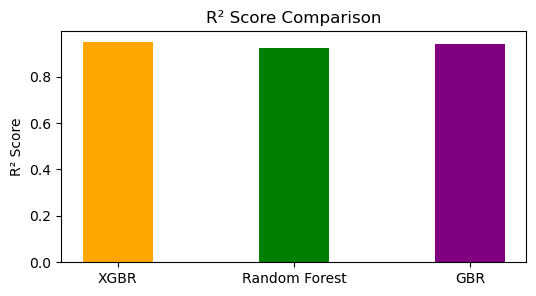

In [47]:
final_result = pd.DataFrame({
    "Models": ['XGBR', 'Random Forest', 'GBR'],
    "R2": [xgb_tuned_r2, rf_tuned_r2, gbr_tuned_r2]
})

plt.figure(figsize=(6,3))
plt.bar(final_result["Models"], final_result["R2"], color=["orange", "green", "purple"], width = 0.4)
plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.show()

## Model Analysis Report After Hyperparameter Tuning

After performing **hyperparameter tuning**, three regression models were evaluated using the **R² score** to determine their predictive performance.

| Model             |     R² Score | Performance  |
| ----------------- | -----------: | ------------ |
| **XGBR**          | **0.947609** | 🥇 Best      |
| **GBR**           | **0.939696** | 🥈 Very Good |
| **Random Forest** | **0.923995** | 🥉 Good      |

### Analysis

The tuned **XGBoost Regressor (XGBR)** achieved the highest R² score of **0.947609**, indicating that it explains approximately **94.76% of the variation in flight ticket prices**. Therefore, XGBR performed better than the other tuned models.

The **Gradient Boosting Regressor (GBR)** achieved an R² score of **0.939696**, explaining approximately **93.97% of the variation**. Its performance is very close to XGBR, making it a strong alternative model.

The **Random Forest Regressor** obtained an R² score of **0.923995**, explaining approximately **92.40% of the variation**. Although it performed well, its predictive performance was lower than both boosting-based models.


# Actual vs Predicted Price

In [48]:
best_model = best_xgb

y_pred = best_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
print("Final Model Performance: ")
print("R2: ",r2)

Final Model Performance: 
R2:  0.9476089949346628


In [49]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,9.673760,9.585208
1,9.032051,9.096610
2,8.279951,8.266506
3,8.997889,9.076939
4,8.306472,8.473409
5,8.448700,8.484974
6,9.342421,9.444558
7,8.935245,8.945271
8,8.979039,8.989843
9,9.448806,9.471989


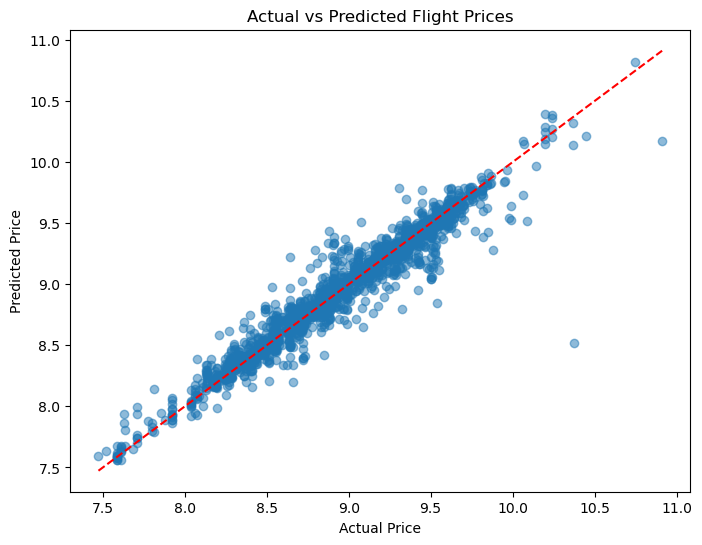

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.show()


## Model Saving

In [51]:
import joblib

joblib.dump(xgb_model, "flight_price_model.pkl")

['flight_price_model.pkl']

# Conclusion

After hyperparameter tuning, **XGBR was selected as the final model** because it achieved the highest R² score of **0.947609**. The results demonstrate that the tuned models are capable of predicting flight ticket prices effectively, with **XGBR providing the best overall performance among the evaluated models**.

## Project Contribution

- Performed data cleaning and preprocessing on the flight fare dataset.
- Conducted univariate, bivariate, and outlier analysis.
- Performed feature engineering on date, time, duration, and number of stops.
- Applied encoding techniques to categorical features.
- Trained multiple regression models including Random Forest, Gradient Boosting, and XGBoost.
- Performed hyperparameter tuning to improve model performance.
- Evaluated models using R², MAE, MSE, and RMSE.
- Compared the performance of different models and selected the best-performing model.
- Achieved an **R² score of 0.947609 using XGBoost Regressor (XGBR)**.
- Saved the final trained model for future predictions and deployment.

## Challenges Faced and Techniques Used

During the analysis of the flight price dataset, several data-related challenges were identified. Appropriate data preprocessing and feature engineering techniques were applied to prepare the dataset for analysis and machine learning.

| Challenge | Technique Used | Reason |
|---|---|---|
| Missing values | Missing-value detection and handling | To avoid errors and improve data quality |
| Duplicate records | Duplicate detection and removal | To prevent repeated observations from affecting the analysis |
| Date stored as text | Date conversion and feature extraction | To extract useful features such as day, month, and year |
| Time stored as text | Hour extraction | To convert departure and arrival times into useful numerical features |
| Duration stored as text | Converted duration into minutes | To make flight duration suitable for machine-learning models |
| Categorical variables | Label Encoding | To convert categorical data into numerical format |
| Price outliers | Boxplot and IQR method | To identify unusually high or low ticket prices |
| Different data types | Feature engineering and preprocessing | To make the dataset suitable for analysis and prediction |

### Summary

The main challenge was the presence of different types of data, including categorical, numerical, date, time, and text variables. Data cleaning, feature engineering, and encoding techniques were therefore applied to transform the raw dataset into a structured format suitable for exploratory data analysis and machine-learning modeling.
